In [11]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    accuracy_score
)


In [12]:

df = pd.read_csv("hospital_readmission.csv")

print("First 5 rows of dataset:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

First 5 rows of dataset:
  patient_id  age primary_diagnosis  num_diagnoses  prior_visits_12mo  \
0    P100000   70              copd              3                  2   
1    P100001   49         pneumonia              1                  1   
2    P100002   76         pneumonia              4                  1   
3    P100003   79         pneumonia              1                  0   
4    P100004   36              copd              3                  0   

   length_of_stay_days  systolic_bp  diastolic_bp  heart_rate  glucose_level  \
0                    7          113            91          92            144   
1                    6          149            72          58            129   
2                    1          141            86          73            136   
3                    8          119           102          93            127   
4                   14          110            78          80            107   

    bmi  has_diabetes  has_hypertension  has_ckd  polyp

In [13]:
X = df.drop(columns=["readmitted_30d", "patient_id"])

y = df["readmitted_30d"]



In [14]:
numeric = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical = X.select_dtypes(
    include=["object"]
).columns

print("\nNumerical columns:")
print(list(numeric))

print("\nCategorical columns:")
print(list(categorical))



Numerical columns:
['age', 'num_diagnoses', 'prior_visits_12mo', 'length_of_stay_days', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'glucose_level', 'bmi', 'has_diabetes', 'has_hypertension', 'has_ckd', 'polypharmacy']

Categorical columns:
['primary_diagnosis', 'discharge_disposition', 'insurance_type']


In [15]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


In [16]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])


In [17]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric),
    ("cat", categorical_pipeline, categorical)
])


In [18]:
model = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=1000
    ))
])

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))



Training samples: 4000
Testing samples: 1000


In [20]:
model.fit(X_train, y_train)

print("\nModel training completed.")




Model training completed.


In [22]:
y_pred = model.predict(X_test)



y_prob = model.predict_proba(X_test)[:, 1]

In [23]:

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)



Accuracy: 0.787


In [24]:
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)



ROC-AUC: 0.6862179487179488


In [25]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)



Confusion Matrix:
[[748  32]
 [181  39]]


In [26]:
print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.96      0.88       780
           1       0.55      0.18      0.27       220

    accuracy                           0.79      1000
   macro avg       0.68      0.57      0.57      1000
weighted avg       0.75      0.79      0.74      1000



In [27]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

print("\nConfusion Matrix Details:")
print("True Negative (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive (TP):", tp)


Confusion Matrix Details:
True Negative (TN): 748
False Positive (FP): 32
False Negative (FN): 181
True Positive (TP): 39


In [28]:
recall = tp / (tp + fn)

print("\nRecall / Sensitivity:", recall)



Recall / Sensitivity: 0.17727272727272728


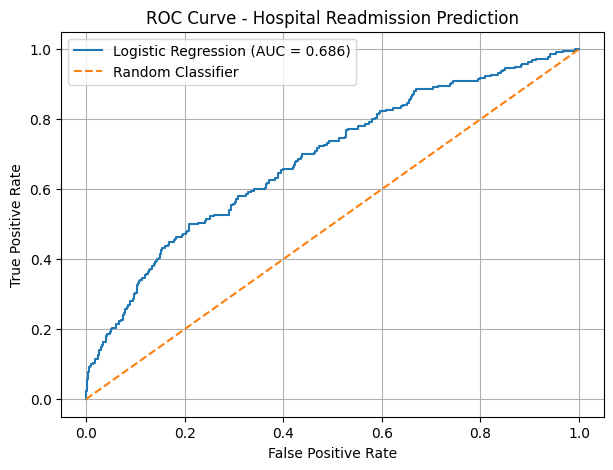

In [29]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Hospital Readmission Prediction")

plt.legend()

plt.grid()

plt.show()

In [31]:
print("\n" + "=" * 60)
print("CLINICAL INTERPRETATION")
print("=" * 60)

print("\nFalse Negative:")
print(
    "A patient who will actually be readmitted within 30 days "
    "is predicted as low-risk."
)

print(
    "Clinical cost: This may delay follow-up, monitoring, "
    "or intervention and could increase the risk of a missed "
    "readmission."
)


print("\nFalse Positive:")
print(
    "A patient who will not be readmitted within 30 days "
    "is predicted as high-risk."
)

print(
    "Clinical cost: This may result in unnecessary follow-up, "
    "additional monitoring, and increased healthcare resource use."
)



CLINICAL INTERPRETATION

False Negative:
A patient who will actually be readmitted within 30 days is predicted as low-risk.
Clinical cost: This may delay follow-up, monitoring, or intervention and could increase the risk of a missed readmission.

False Positive:
A patient who will not be readmitted within 30 days is predicted as high-risk.
Clinical cost: This may result in unnecessary follow-up, additional monitoring, and increased healthcare resource use.


In [32]:
print("\n" + "=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print("Model: Logistic Regression")
print("Regularization: L2")
print("Regularization parameter C:", 1.0)
print("Accuracy:", round(accuracy, 4))
print("ROC-AUC:", round(auc, 4))
print("False Positives:", fp)
print("False Negatives:", fn)


FINAL MODEL SUMMARY
Model: Logistic Regression
Regularization: L2
Regularization parameter C: 1.0
Accuracy: 0.787
ROC-AUC: 0.6862
False Positives: 32
False Negatives: 181
